In [11]:
"""
Generate dataset from data labeled by www.labelstud.io
"""
import cv2
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import sys
from model_utils import *
import shutil

In [12]:
train_labels =f"{TRAIN_DATA_DIR}/labels"
test_labels = f"{TEST_DATA_DIR}/labels"
for dir_name in [train_labels, test_labels]:
    files = glob.glob(os.path.join(dir_name, "*.png"))
    for file in files:
        img = cv2.imread(file, cv2.IMREAD_UNCHANGED)
        unique_values = np.unique(img)
        if len(unique_values) > 2:
            print(f"Warning: {file} has more than 2 unique pixel values: {unique_values}")
            sys.exit(1)

In [35]:
def delete_seg_dir(dir):
    if os.path.exists(dir):
        seg_dir = f"{dir}/segmentations"
        if os.path.exists(seg_dir):
            shutil.rmtree(seg_dir)
            os.makedirs(seg_dir)
            print(seg_dir)
        else:
            os.makedirs(seg_dir)
delete_seg_dir(TRAIN_DATA_DIR)
delete_seg_dir(TEST_DATA_DIR)

train_data_v2/segmentations
test_data_v2/segmentations


files

Found 139 files in test_data_v2/labels, with num_tasks=30
task-4- with mask for label 4
task-4- with mask for label 15
task-4- with mask for label 12


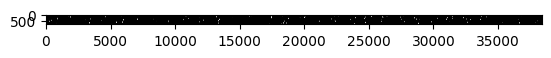

In [ ]:
def generate_combined_segmentation(data_dir):

    files = glob.glob(os.path.join(f"{data_dir}/labels", "*.png"))
    num_tasks = glob.glob(os.path.join(f"{data_dir}/test_images", "*.png"))
    print(f"Found {len(files)} files in {data_dir}/labels, with num_tasks={len(num_tasks)}")
    data = []
    for idx in range(len(num_tasks)):
        fname = "task-" + str(idx + 1) + "-"
        mask = np.zeros((720, 1280), dtype=np.float32)
        for file in files:
            if file.find(fname) != -1:
                img = cv2.imread(file, cv2.IMREAD_UNCHANGED) # (720, 1280)
                label_id = file.split('-')[-1].split('.')[0]
                mask[img > 0] = label_id
              
        data.append(mask)
        # print(mask.shape)
        cv2.imwrite(f"{data_dir}/segmentations/seg_" + str(idx + 1) + ".png", mask)

    img_pair = np.concatenate([img for img in data], axis=1)

    plt.imshow(img_pair*(255/NUM_CLASSES), cmap='gray')
    plt.show()
generate_combined_segmentation(TEST_DATA_DIR)
generate_combined_segmentation(TRAIN_DATA_DIR)

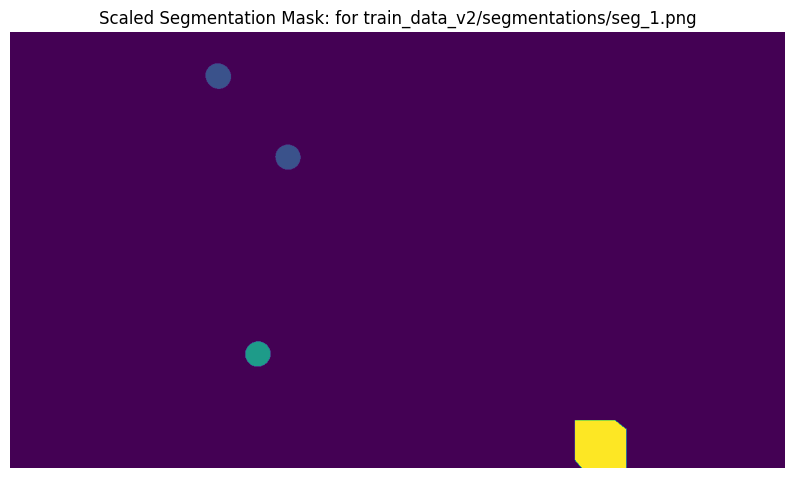

In [40]:


files = glob.glob(os.path.join(f"{TRAIN_DATA_DIR}/segmentations", "seg_*.png"))
files.sort(key=lambda x: int(os.path.basename(x).split('_')[-1].split('.')[0]))

file_num = 0
# Load the first mask
mask = cv2.imread(files[file_num], cv2.IMREAD_UNCHANGED)  # shape (H, W)

mask_scaled = mask.astype(np.float32) * (255 / (NUM_CLASSES))

# Display using matplotlib
plt.figure(figsize=(10, 6))
plt.imshow(mask_scaled)
plt.title(f"Scaled Segmentation Mask: for {files[file_num]}")
plt.axis('off')
plt.show()